### Gruppenmitglieder:
- brni1027
- obha1011

# Aufgabe 1
## a)

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'C:\Users\Hagen\OneDrive\HKA\SS26\Umweltmonitoring\Preisach (Mi)\Arbeitsblätter\AB3\Umweltmonitoring-AB3\co2_mlo_surface-flask_1_ccgg_event.txt', 
                  sep=' ',          # Trennzeichen
                  comment='#',       # Kommentarzeilen ignorieren
                  decimal='.')       # Dezimaltrennzeichen

df.info()
df.describe()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10940 entries, 0 to 10939
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   site_code                10940 non-null  object 
 1   year                     10940 non-null  int64  
 2   month                    10940 non-null  int64  
 3   day                      10940 non-null  int64  
 4   hour                     10940 non-null  int64  
 5   minute                   10940 non-null  int64  
 6   second                   10940 non-null  int64  
 7   datetime                 10940 non-null  object 
 8   time_decimal             10940 non-null  float64
 9   air_sample_container_id  10940 non-null  object 
 10  value                    10940 non-null  float64
 11  value_unc                10940 non-null  float64
 12  latitude                 10940 non-null  float64
 13  longitude                10940 non-null  float64
 14  altitude              

,site_code,year,month,day,hour,minute,second,datetime,time_decimal,air_sample_container_id,...,latitude,longitude,altitude,elevation,intake_height,method,event_number,instrument,analysis_datetime,qcflag
0,MLO,1969,8,20,17,55,0,1969-08-20T17:55:00Z,1969.634922,33-69,...,19.5300,-155.5800,3399.0,3397.0,2.0,N,78808,LR1,1969-09-09T09:02:00,...
1,MLO,1969,8,20,17,55,0,1969-08-20T17:55:00Z,1969.634922,34-69,...,19.5300,-155.5800,3399.0,3397.0,2.0,N,78809,LR1,1969-09-09T09:12:00,C..
2,MLO,1969,8,20,18,30,0,1969-08-20T18:30:00Z,1969.634989,31-69,...,19.5300,-155.5800,3399.0,3397.0,2.0,N,78810,LR1,1969-09-09T08:58:00,M..
3,MLO,1969,8,20,18,30,0,1969-08-20T18:30:00Z,1969.634989,32-69,...,19.5300,-155.5800,3399.0,3397.0,2.0,N,78811,LR1,1969-09-09T09:00:00,M..
4,MLO,1969,8,27,19,15,0,1969-08-27T19:15:00Z,1969.654252,35-69,...,19.5300,-155.5800,3399.0,3397.0,2.0,N,78812,LR1,1969-09-09T08:42:00,M..
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10935,MLO,2024,12,24,19,17,0,2024-12-24T19:17:00Z,2024.980337,2242-99,...,19.5362,-155.5763,3437.0,3397.0,40.0,S,545830,PIC-032,2025-03-20T12:14:29,...
10936,MLO,2024,12,31,19,40,0,2024-12-31T19:40:00Z,2024.999507,1282-99,...,19.5362,-155.5763,3402.0,3397.0,5.0,P,547491,PIC-032,2025-03-21T14:19:50,...
10937,MLO,2024,12,31,19,40,0,2024-12-31T19:40:00Z,2024.999507,5182-99,...,19.5362,-155.5763,3402.0,3397.0,5.0,P,547492,PIC-032,2025-03-21T14:34:17,...
10938,MLO,2024,12,31,19,43,0,2024-12-31T19:43:00Z,2024.999512,2683-99,...,19.5362,-155.5763,3437.0,3397.0,40.0,S,547489,PIC-032,2025-03-21T15:17:33,...


In [3]:
if 'datetime' not in df.columns and df.index.name == 'datetime':
    df = df.reset_index()

df['datetime'] = pd.to_datetime(df['datetime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10940 entries, 0 to 10939
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   site_code                10940 non-null  object             
 1   year                     10940 non-null  int64              
 2   month                    10940 non-null  int64              
 3   day                      10940 non-null  int64              
 4   hour                     10940 non-null  int64              
 5   minute                   10940 non-null  int64              
 6   second                   10940 non-null  int64              
 7   datetime                 10940 non-null  datetime64[ns, UTC]
 8   time_decimal             10940 non-null  float64            
 9   air_sample_container_id  10940 non-null  object             
 10  value                    10940 non-null  float64            
 11  value_unc                109

In [4]:
# Datenbereinigung: Platzhalterwerte und Qualitätsfilter
df_clean = df.copy()

# NOAA-Platzhalter für ungültige CO2-Werte zu NaN machen (numerischer Typ bleibt erhalten)
df_clean['value'] = df_clean['value'].replace(-999.99, np.nan)

# Nur qualitativ unauffällige Messungen behalten
if 'qcflag' in df_clean.columns:
    df_clean = df_clean[df_clean['qcflag'] == '...'].copy()

# Zeilen ohne gültigen CO2-Wert entfernen
df_clean = df_clean.dropna(subset=['value'])

In [5]:
# Summary Statistics: Global und pro Jahrzehnt

# Sicherstellen, dass datetime als DatetimeIndex vorliegt
if not isinstance(df_clean.index, pd.DatetimeIndex):
    if 'datetime' in df_clean.columns:
        df_clean['datetime'] = pd.to_datetime(df_clean['datetime'], errors='coerce')
        df_clean = df_clean.dropna(subset=['datetime']).set_index('datetime')

# Jahrzehnt extrahieren
df_clean['year'] = df_clean.index.year
df_clean['decade'] = (df_clean['year'] // 10) * 10

# Global Statistics
print("=" * 70)
print("GLOBAL STATISTICS (alle bereinigten Daten)")
print("=" * 70)
global_stats = df_clean['value'].describe().round(3)
print(global_stats)

print("\n" + "=" * 70)
print("STATISTICS PRO JAHRZEHNT")
print("=" * 70)

# Pro Jahrzehnt: min, max, mean, median, std
decades_list = sorted(df_clean['decade'].unique())
decade_stats = []

for d in decades_list:
    decade_data = df_clean[df_clean['decade'] == d]['value']
    decade_stats.append({
        'Jahrzehnt': f"{d}er",
        'count': int(decade_data.count()),
        'min': round(decade_data.min(), 3),
        'max': round(decade_data.max(), 3),
        'mean': round(decade_data.mean(), 3),
        'median': round(decade_data.median(), 3),
        'std': round(decade_data.std(), 3),
    })

decade_df = pd.DataFrame(decade_stats).set_index('Jahrzehnt')
print(decade_df.to_string())


GLOBAL STATISTICS (alle bereinigten Daten)
count    9913.000
mean      372.876
std        25.796
min       320.230
25%       351.080
50%       368.700
75%       393.560
max       427.760
Name: value, dtype: float64

STATISTICS PRO JAHRZEHNT
           count     min     max     mean   median    std
Jahrzehnt                                                
1960er        29  320.23  323.31  321.608  321.300  1.119
1970er       358  322.35  340.18  332.869  333.465  4.210
1980er      2537  335.36  357.29  346.602  346.653  4.562
1990er      2093  349.88  372.14  359.974  359.140  5.111
2000er      1982  366.56  391.06  378.938  379.140  6.100
2010er      1969  385.56  415.49  400.484  400.210  7.307
2020er       945  410.80  427.76  418.479  418.480  4.026


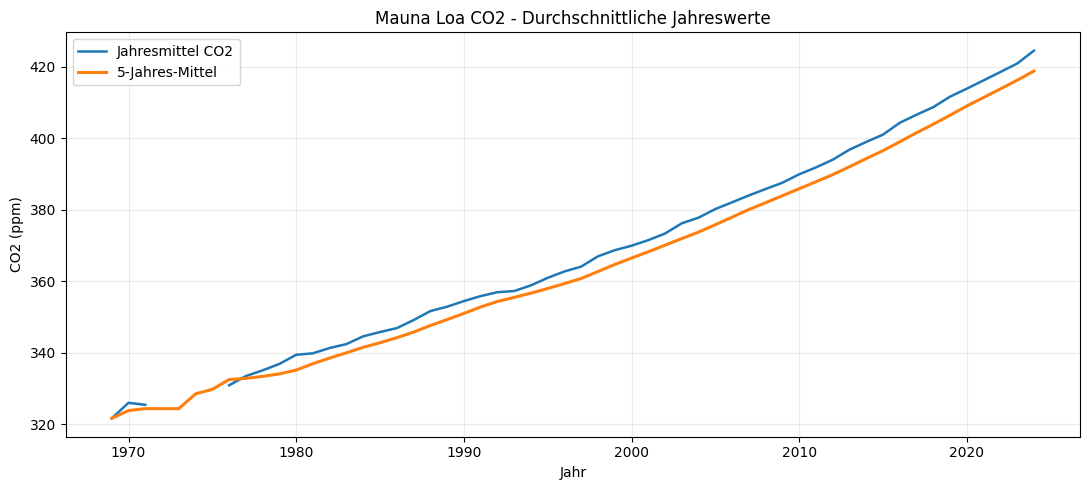

In [6]:
import matplotlib.pyplot as plt

# Sicherstellen, dass datetime als DatetimeIndex vorliegt
if not isinstance(df_clean.index, pd.DatetimeIndex):
    if 'datetime' in df_clean.columns:
        df_clean['datetime'] = pd.to_datetime(df_clean['datetime'], errors='coerce')
        df_clean = df_clean.dropna(subset=['datetime']).set_index('datetime')

# 1) Durchschnittliche Jahreswerte (Liniengraph)
annual_mean = df_clean['value'].resample('YE').mean()
annual_mean.index = annual_mean.index.year

plt.figure(figsize=(11, 5))
plt.plot(annual_mean.index, annual_mean.values, color='tab:blue', linewidth=1.8, label='Jahresmittel CO2')
plt.plot(annual_mean.index, annual_mean.rolling(5, min_periods=1).mean(),
         color='tab:orange', linewidth=2.2, label='5-Jahres-Mittel')
plt.title('Mauna Loa CO2 - Durchschnittliche Jahreswerte')
plt.xlabel('Jahr')
plt.ylabel('CO2 (ppm)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## b)

In [7]:
# Perioden: (Startjahr, Endjahr)
perioden = {
    '1980–1989': (1980, 1989),
    '2000–2009': (2000, 2009),
    '2010–2019': (2010, 2019),
    '2020–2024': (2020, 2024),
}

ergebnisse = []
for label, (start_yr, end_yr) in perioden.items():
    start_val = annual_mean[start_yr]
    end_val   = annual_mean[end_yr]
    jahre     = end_yr - start_yr
    cagr_rel  = (end_val / start_val) ** (1 / jahre) - 1   # dimensionslos
    cagr_ppm  = cagr_rel * start_val                        # ppm/Jahr
    ergebnisse.append({
        'Periode':           label,
        'Startwert (ppm)':   round(start_val, 2),
        'Endwert (ppm)':     round(end_val, 2),
        'Jahre':             jahre,
        'CAGR (ppm/Jahr)':   round(cagr_ppm, 4),
        'CAGR (%)':          round(cagr_rel * 100, 4),
    })

cagr_df = pd.DataFrame(ergebnisse).set_index('Periode')
print(cagr_df.to_string())

           Startwert (ppm)  Endwert (ppm)  Jahre  CAGR (ppm/Jahr)  CAGR (%)
Periode                                                                    
1980–1989           339.40         352.86      9           1.4701    0.4331
2000–2009           369.93         387.57      9           1.9189    0.5187
2010–2019           389.93         411.66      9           2.3568    0.6044
2020–2024           413.90         424.52      4           2.6303    0.6355


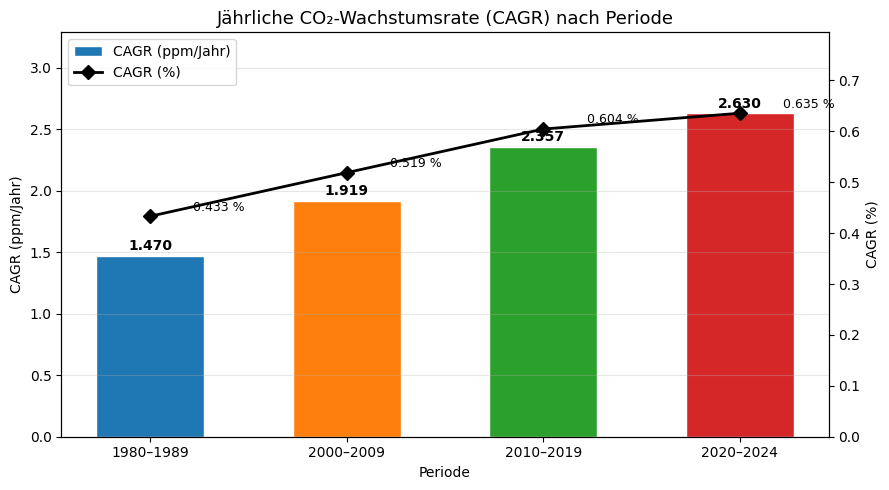

In [8]:
fig, ax1 = plt.subplots(figsize=(9, 5))

perioden_labels = cagr_df.index.tolist()
cagr_werte      = cagr_df['CAGR (ppm/Jahr)'].tolist()
cagr_pct        = cagr_df['CAGR (%)'].tolist()
farben          = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
x               = range(len(perioden_labels))

# Balken: ppm/Jahr (linke Achse)
bars = ax1.bar(x, cagr_werte, color=farben, width=0.55, edgecolor='white', label='CAGR (ppm/Jahr)')
ax1.set_ylabel('CAGR (ppm/Jahr)', color='black')
ax1.set_ylim(0, max(cagr_werte) * 1.25)
ax1.set_xticks(x)
ax1.set_xticklabels(perioden_labels)
ax1.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, cagr_werte):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Linie: % (rechte Achse)
ax2 = ax1.twinx()
ax2.plot(x, cagr_pct, color='black', linewidth=2, marker='D',
         markersize=7, label='CAGR (%)', zorder=5)
ax2.set_ylabel('CAGR (%)', color='black')
ax2.set_ylim(0, max(cagr_pct) * 1.25)

for xi, val in zip(x, cagr_pct):
    ax2.text(xi + 0.22, val + 0.005, f'{val:.3f} %', va='bottom', fontsize=9, color='black')

# Legende kombinieren
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Jährliche CO₂-Wachstumsrate (CAGR) nach Periode', fontsize=13)
ax1.set_xlabel('Periode')
plt.tight_layout() 
plt.show()

### Interpretation

Die CAGR-Werte zeigen eine klare **Beschleunigung des CO₂-Anstiegs** über die betrachteten Zeiträume:

- **1980–1989:** Die niedrigste Wachstumsrate der vier Perioden. Der CO₂-Anstieg war in diesem Jahrzehnt noch vergleichsweise moderat, obwohl die Industrialisierung und der Energieverbrauch weltweit zunahmen.
- **2000–2009:** Die Rate steigt deutlich gegenüber den 1980er Jahren. Starkes Wirtschaftswachstum – insbesondere in Schwellenländern wie China und Indien – sowie die zunehmende globale Energienachfrage treiben die Emissionen weiter in die Höhe.
- **2010–2019:** Die Wachstumsrate ist erneut höher als in der Vorperiode und erreicht einen neuen Höchststand unter den Jahrzehnten. Trotz eines wachsenden Ausbaus erneuerbarer Energien überwiegen global weiterhin fossile Brennstoffe.
- **2020–2024:** Die Rate liegt auf ähnlichem Niveau wie 2010–2019 oder leicht darunter. Der pandemiebedinge Einbruch 2020 hat die Emissionen kurzfristig reduziert, jedoch kam es danach zu einem raschen Rebound. Der anhaltend hohe Wert zeigt, dass die bisherigen Klimaschutzmaßnahmen den absoluten CO₂-Anstieg bislang nicht bremsen konnten.

**Fazit:** Die Beschleunigung des CO₂-Anstiegs von den 1980er Jahren bis in die 2010er Jahre spiegelt den wachsenden globalen Energiehunger wider. Dass die Rate in 2020–2024 nicht weiter gestiegen ist, könnte ein erstes Zeichen einer Stabilisierung sein – ein echter Rückgang der Wachstumsrate ist bislang jedoch nicht erkennbar.

## c)

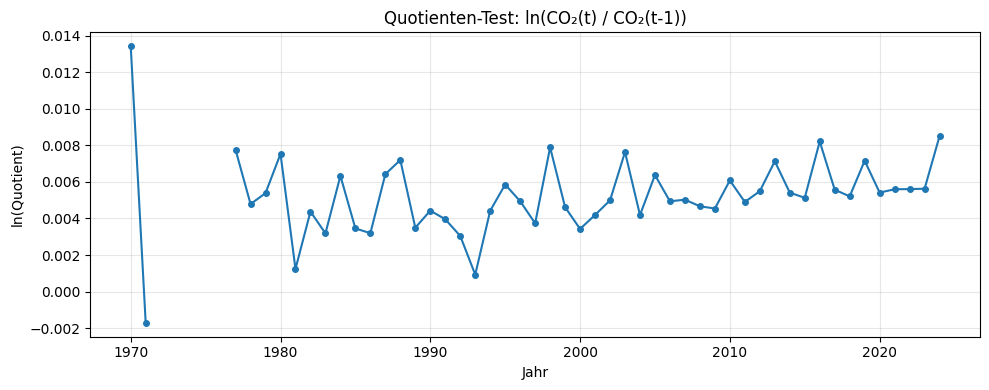

In [13]:
# Quotienten zwischen aufeinanderfolgenden Jahren
quotient = annual_mean[1:].values / annual_mean[:-1].values
log_quotient = np.log(quotient)
jahre = annual_mean.index[1:]

plt.figure(figsize=(10, 4))
plt.plot(jahre, log_quotient, 'o-', markersize=4)
plt.title('Quotienten-Test: ln(CO₂(t) / CO₂(t-1))')
plt.xlabel('Jahr')
plt.ylabel('ln(Quotient)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

Wenn `ln(CO₂(t) / CO₂(t-1))` **konstant** ist (horizontale Linie), dann ist das Wachstum **exponentiell**.

Der Plot zeigt, dass die Werte um einen Mittelwert schwanken, insgesamt aber **ungefähr konstant** bleiben. Das deutet auf **näherungsweise exponentielles Wachstum** hin. Die Variationen entstehen durch natürliche Fluktuationen und die leichte Beschleunigung der CO₂-Emissionen über die Zeit.